# News vendor problem

## Imports

In [1]:
from news_vendor.items import Item
from news_vendor.demand_distribution import NormalDemand, SampledDemand
from news_vendor.solvers import SingleItemNewsvendorSolver, MultiItemConstrainedSolver, LagrangianConstraintSolver

from news_vendor.plotting import NewsvendorVisualizer 
import numpy as np

c:\Users\bouwe\OneDrive\Desktop\GitCode\NewsVendorProblem\news_vendor\solvers.py:150: SyntaxWarning: invalid escape sequence '\l'
  """


## Single Item problem

### Normal Distribution

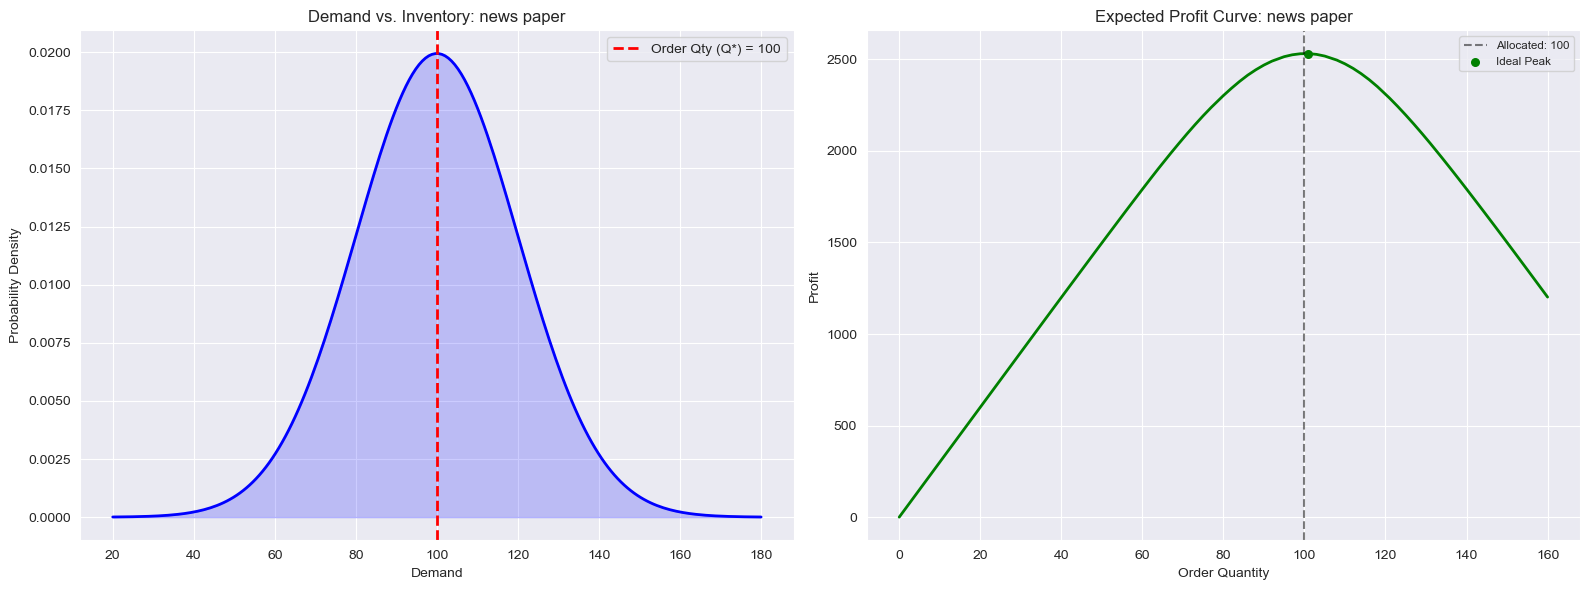

In [2]:
newspaper = Item(name="news paper", cost_price=30, selling_price=60, salvage_value=0)
demand = NormalDemand(mean=100, std_dev=20)
solver = SingleItemNewsvendorSolver(item=newspaper, demand_distribution=demand)

# solve
optimal_quantity = solver.solve()

# show results
results = NewsvendorVisualizer().plot_single_item_analysis(newspaper, demand, optimal_quantity)


### Sampled Distribution

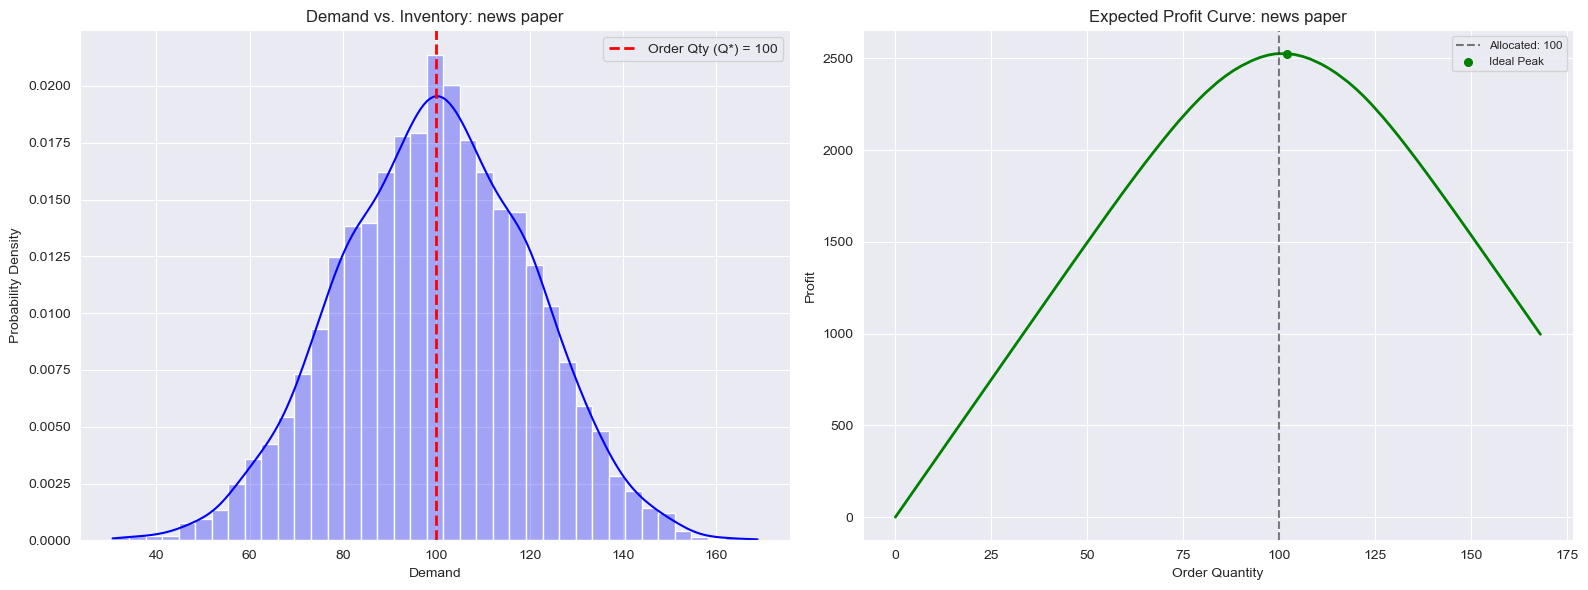

In [3]:
raw_trace_data = np.random.normal(loc=100, scale=20, size=(4, 1000))
    
# The class will handle the flattening of the (4, 1000) array automatically
demand = SampledDemand(samples=raw_trace_data)
solver = SingleItemNewsvendorSolver(item=newspaper, demand_distribution=demand)

# solve
optimal_quantity = solver.solve()

# show results
results = NewsvendorVisualizer().plot_single_item_analysis(newspaper, demand, optimal_quantity)


## Multiple Items (with constraint)

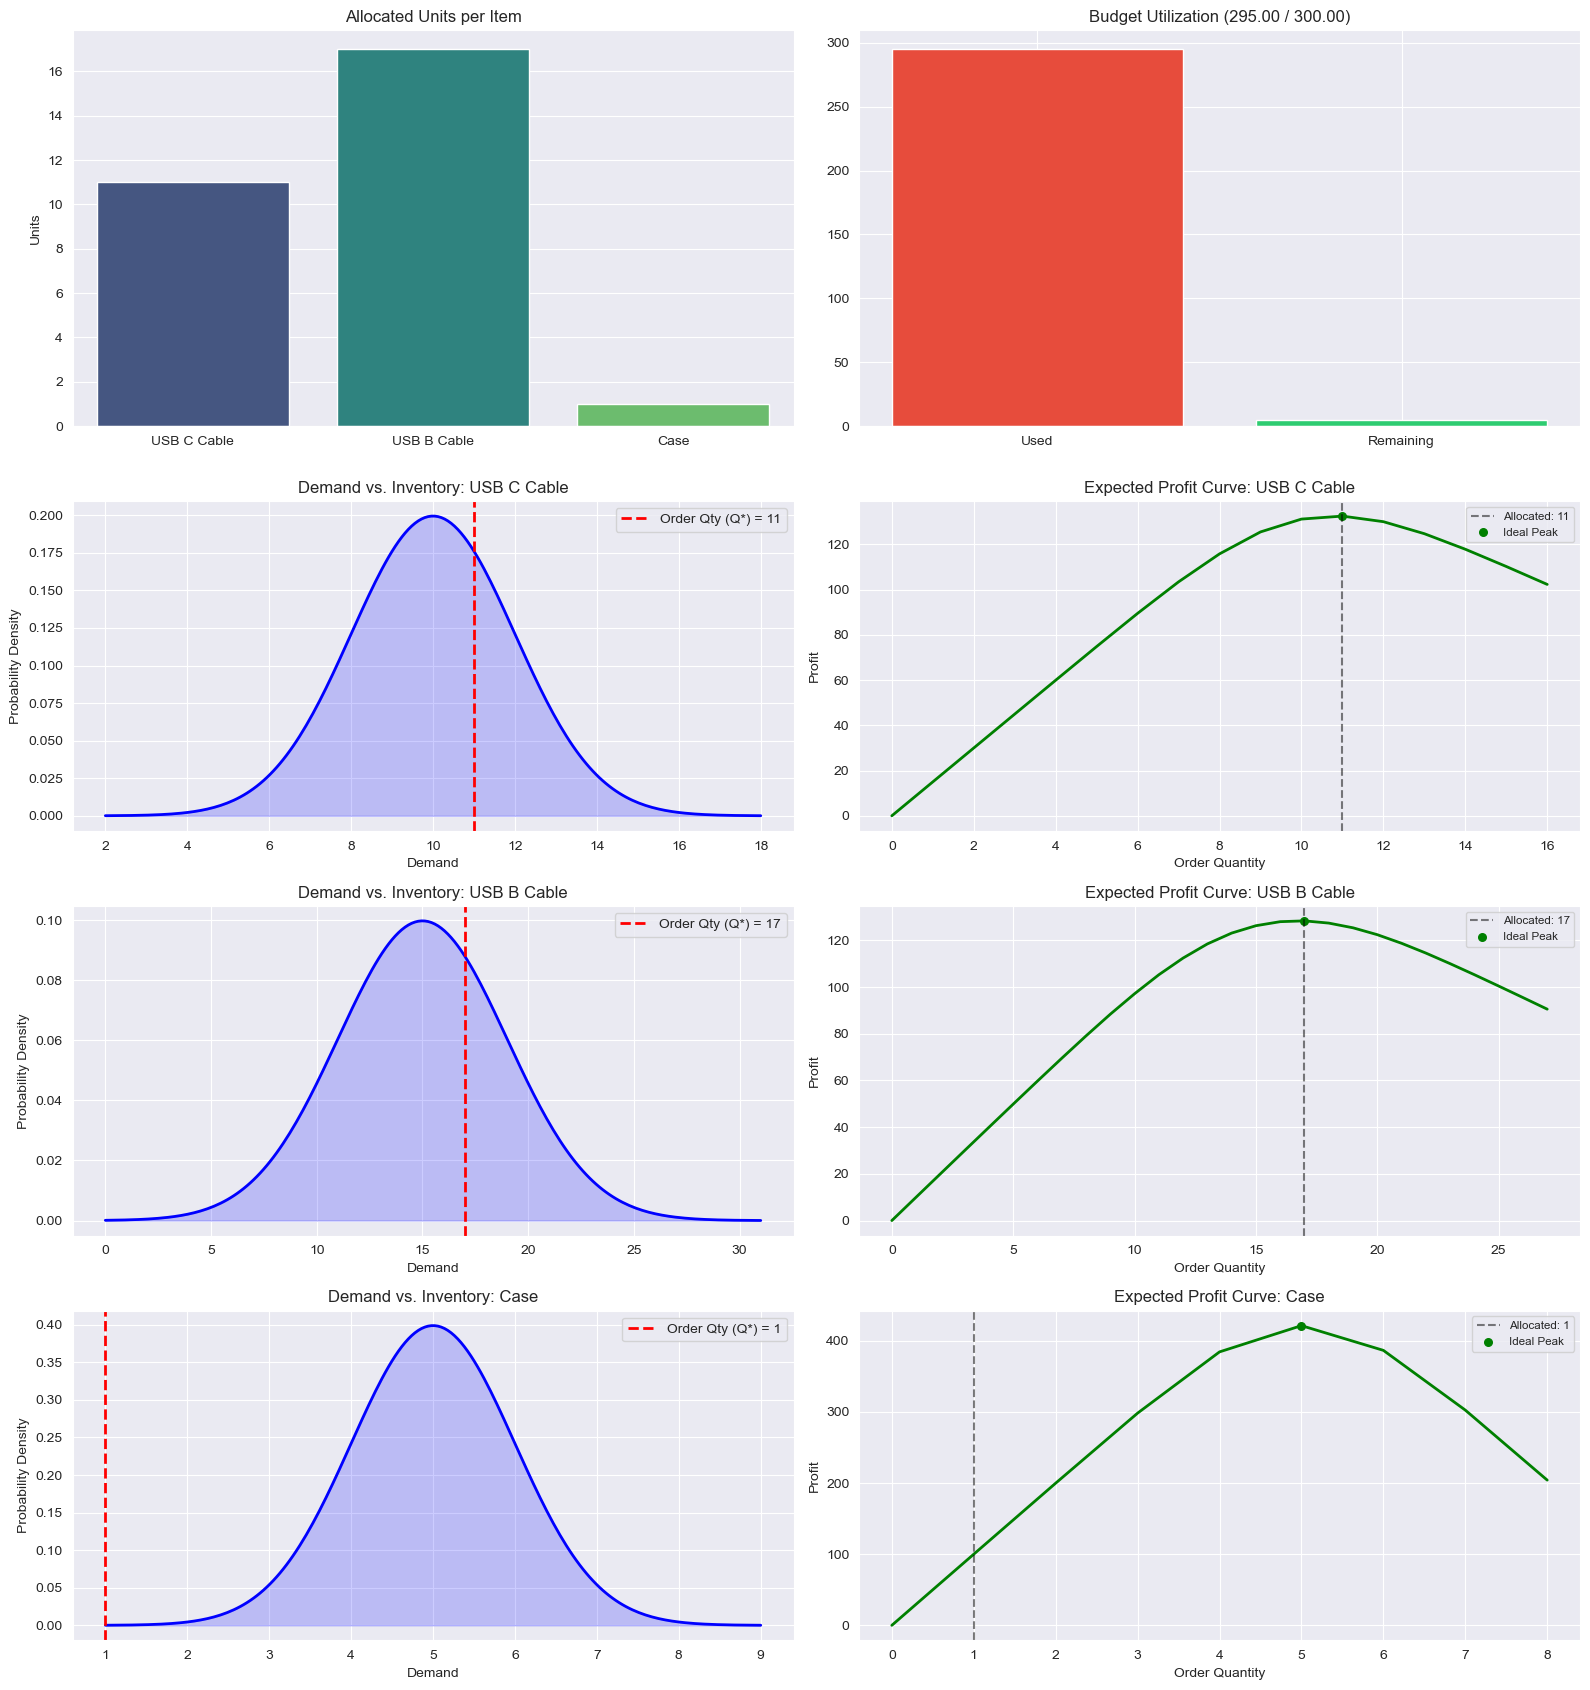

In [4]:
usb_C = Item("USB C Cable", 10, 25, 2)
usb_C_dem = NormalDemand(10, 2)

usb_B = Item("USB B Cable", 5, 15, 0)
usb_B_dem = NormalDemand(15, 4)

Case = Item("Case", 100, 200, 0)
Case_dem = NormalDemand(5, 1)

problems = [(usb_C, usb_C_dem), (usb_B, usb_B_dem), (Case, Case_dem)]

solver = MultiItemConstrainedSolver(problems, budget=300)
allocation = solver.solve()

# show results
results = NewsvendorVisualizer().plot_multi_item_allocation(allocation, problems, budget=300)


## Multiple Items and Constraints

c:\Users\bouwe\OneDrive\Desktop\GitCode\NewsVendorProblem\news_vendor\plotting.py:197: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


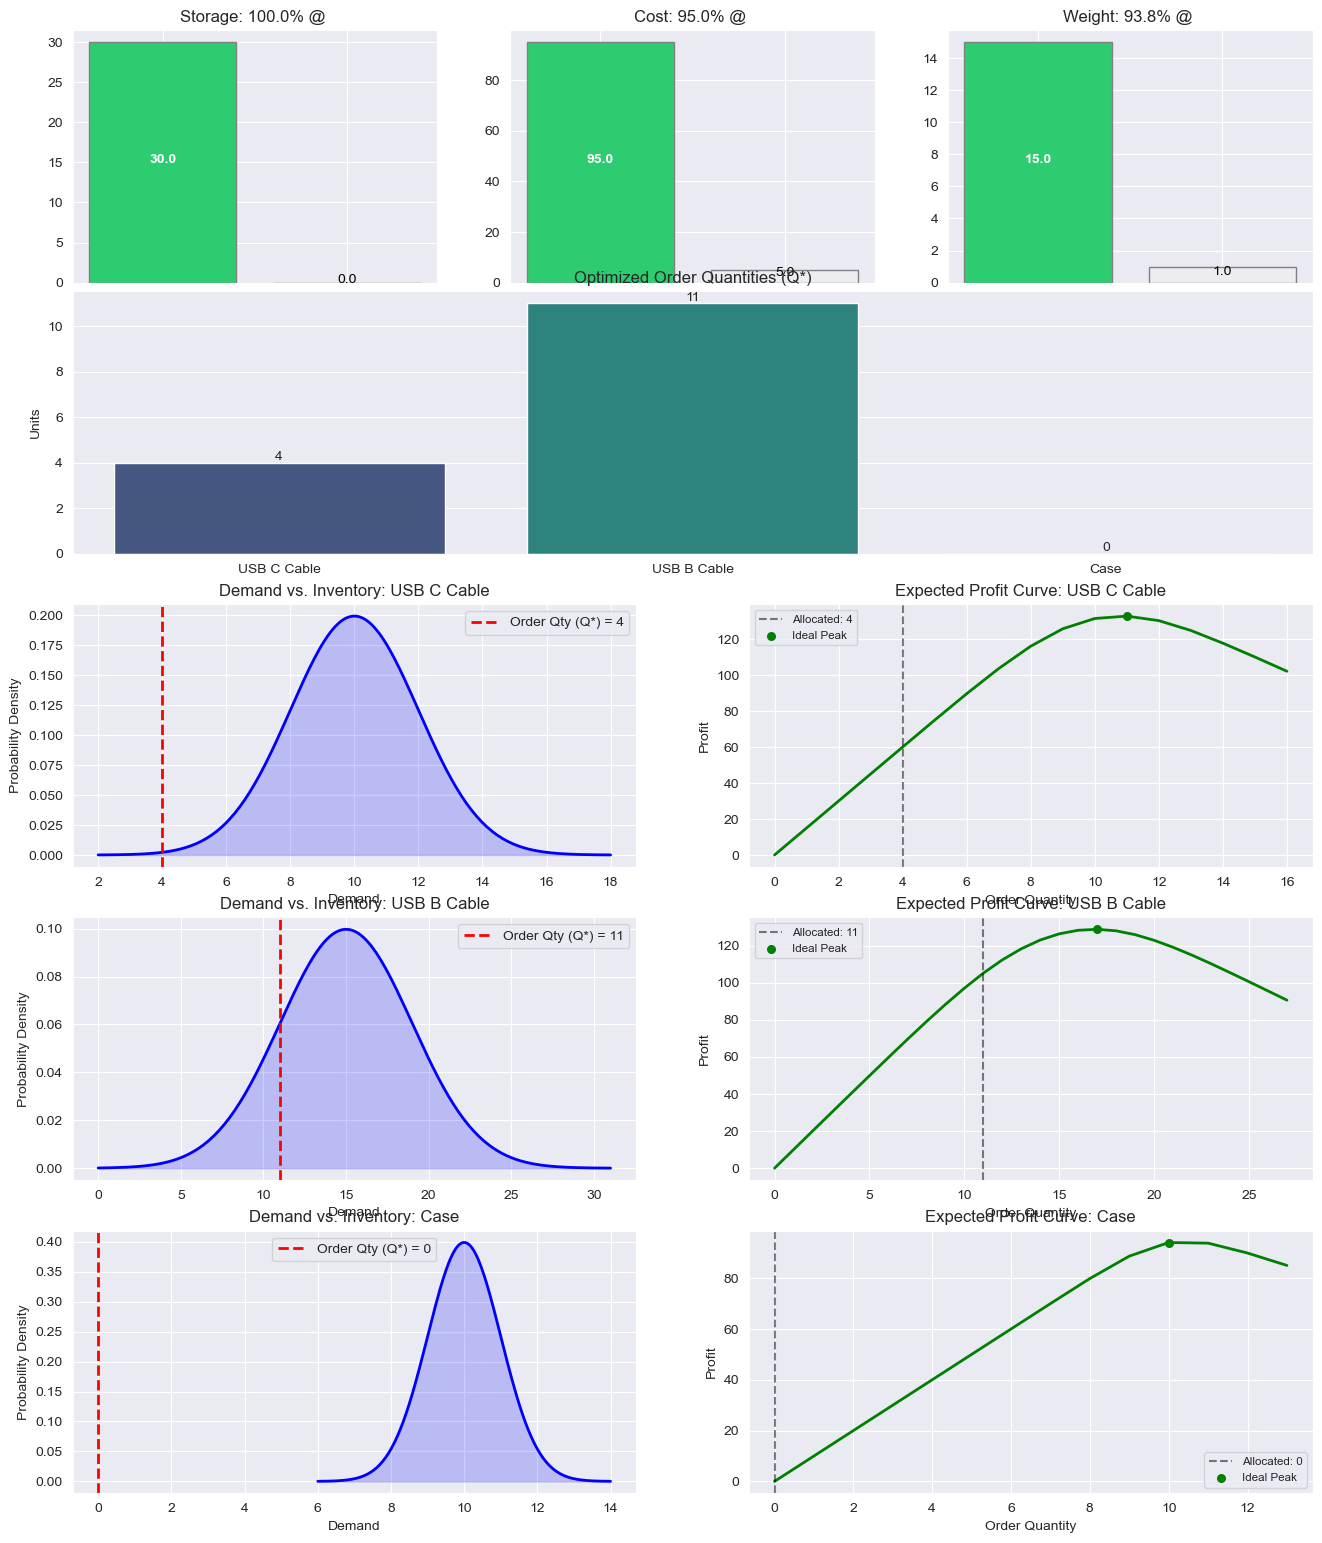

In [8]:
usb_C = Item("USB C Cable", 10, 25, 2, {"storage": 2, "cost": 10, "weight" : 1})
usb_C_dem = NormalDemand(10, 2)

usb_B = Item("USB B Cable", 5, 15, 0, {"storage": 2, "cost": 5, "weight" : 1})
usb_B_dem = NormalDemand(15, 4)

Case = Item("Case", 5, 15, 0, {"storage": 3, "cost": 10, "weight" : 1})
Case_dem = NormalDemand(10, 1)

problems = [(usb_C, usb_C_dem), (usb_B, usb_B_dem), (Case, Case_dem)]

solver = LagrangianConstraintSolver(
    problems, limits={"storage": 30, "cost": 100, "weight" : 16}, learning_rate=1, max_iter=200
)
allocation = solver.solve()

# show results
results = NewsvendorVisualizer().plot_constrained_allocation(
    allocation, problems, solver.limits
)


## View Optimized Results

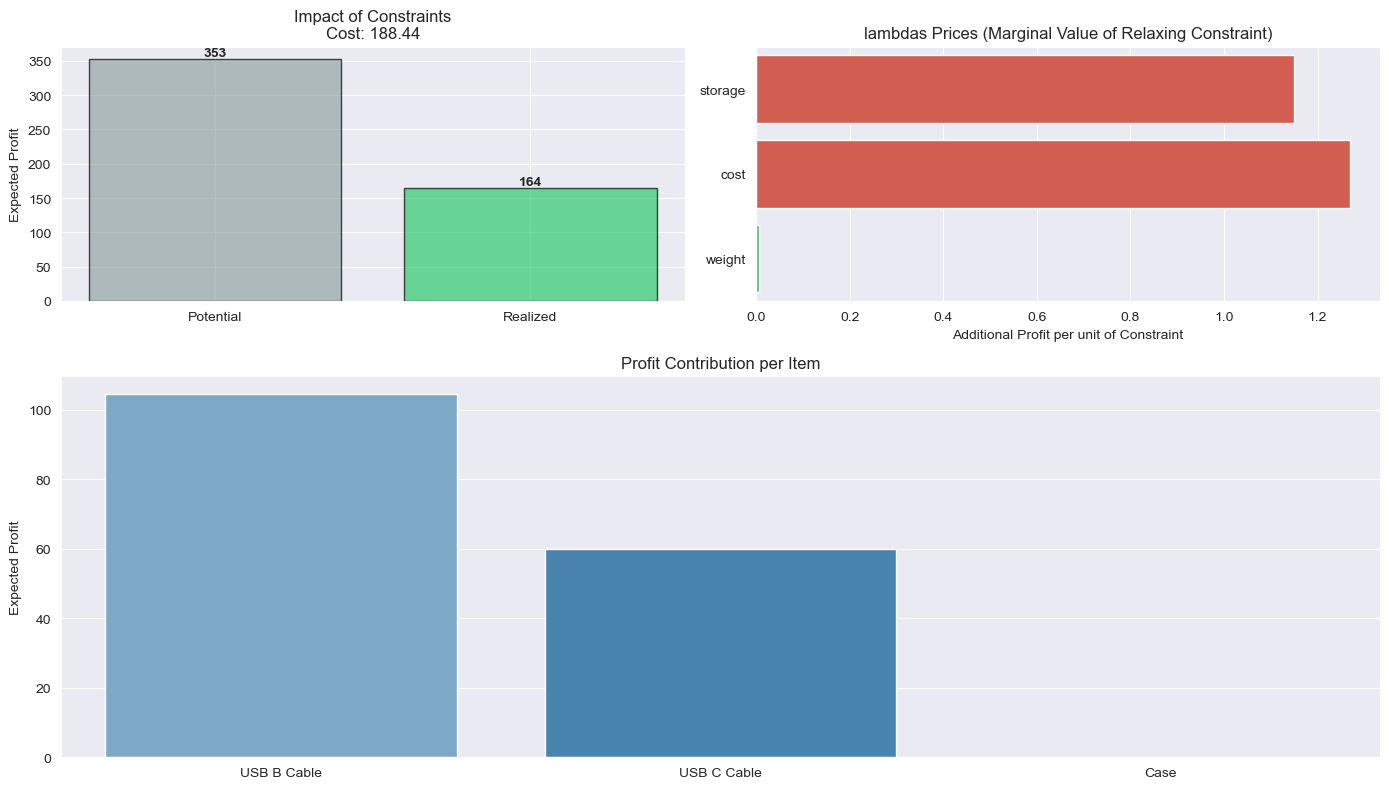

In [9]:
NewsvendorVisualizer().plot_optimization_summary(allocation, problems, solver.lambdas)